In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, shutil, random
from math import ceil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, optimizers
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as eff_preprocess
from sklearn.model_selection import train_test_split

In [ ]:
RAW_ROOT = "/content/drive/MyDrive/Eye Retinal Scans"

SPLIT_ROOT = "/content/retina_dataset_split"
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")

TEST_SIZE = 0.20
RANDOM_STATE = 42

MODEL_NAME = "retina_efficientnetb0"
OUT_DIR = os.path.join("/content", MODEL_NAME)
os.makedirs(OUT_DIR, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_TOP = 6
EPOCHS_FINE = 6
LR_TOP = 1e-4
LR_FINE = 1e-5
DROP_RATE = 0.3
NUM_CLASSES = 4

In [ ]:
import glob
from pathlib import Path

if not os.path.exists(RAW_ROOT):
    raise FileNotFoundError(f"RAW_ROOT not found: {RAW_ROOT}")

classes = sorted([d.name for d in Path(RAW_ROOT).iterdir() if d.is_dir()])
if len(classes) == 0:
    raise SystemExit("No class subfolders found under RAW_ROOT. Each class should be a subfolder.")

print("Found classes:", classes)

def ensure_empty_dir(d):
    if os.path.exists(d):
        print("Cleaning existing folder:", d)
        for root, dirs, files in os.walk(d, topdown=False):
            for name in files:
                os.remove(os.path.join(root, name))
            for name in dirs:
                shutil.rmtree(os.path.join(root, name))
    os.makedirs(d, exist_ok=True)

ensure_empty_dir(SPLIT_ROOT)
for part in ("train","val"):
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_ROOT, part, cls), exist_ok=True)

image_exts = (".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp")
total_counts = {}
for cls in classes:
    cls_path = os.path.join(RAW_ROOT, cls)
    files = [str(p) for p in Path(cls_path).glob("*") if p.suffix.lower() in image_exts]
    files = sorted(files)
    total_counts[cls] = len(files)
    if len(files) == 0:
        print(f"Warning: no images found for class {cls} at {cls_path}")
    train_files, val_files = train_test_split(files, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)
    print(f"Class '{cls}': {len(train_files)} train, {len(val_files)} val (total {len(files)})")

    for src in train_files:
        dst = os.path.join(SPLIT_ROOT, "train", cls, os.path.basename(src))
        shutil.copy2(src, dst)
    for src in val_files:
        dst = os.path.join(SPLIT_ROOT, "val", cls, os.path.basename(src))
        shutil.copy2(src, dst)

print("\nFinal dataset stats in split folder:")
for part in ("train","val"):
    print("->", part)
    for cls in classes:
        cnt = len(list(Path(SPLIT_ROOT, part, cls).glob("*")))
        print(f"   {cls}: {cnt}")

Found classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Class 'cataract': 830 train, 208 val (total 1038)
Class 'diabetic_retinopathy': 878 train, 220 val (total 1098)
Class 'glaucoma': 805 train, 202 val (total 1007)
Class 'normal': 859 train, 215 val (total 1074)

Final dataset stats in split folder:
-> train
   cataract: 830
   diabetic_retinopathy: 878
   glaucoma: 805
   normal: 859
-> val
   cataract: 208
   diabetic_retinopathy: 220
   glaucoma: 202
   normal: 215


In [ ]:
train_aug = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=15,
    width_shift_range=0.06,
    height_shift_range=0.06,
    zoom_range=0.08,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    fill_mode="nearest"
)
val_aug = ImageDataGenerator(preprocessing_function=eff_preprocess)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_aug.flow_from_directory(
    VAL_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

steps_per_epoch = len(train_gen)
validation_steps = len(val_gen)
print("steps_per_epoch:", steps_per_epoch, "validation_steps:", validation_steps)

index_to_label = {v:k for k,v in train_gen.class_indices.items()}
class_labels = [index_to_label[i] for i in range(len(index_to_label))]
print("class_labels (index->label):", index_to_label)


Found 3372 images belonging to 4 classes.
Found 845 images belonging to 4 classes.
steps_per_epoch: 211 validation_steps: 53
class_labels (index->label): {0: 'cataract', 1: 'diabetic_retinopathy', 2: 'glaucoma', 3: 'normal'}


In [ ]:
def build_effnetb0(input_size=(224,224,3), num_classes=4, drop_rate=0.3):
    inputs = Input(shape=input_size, name="input_image")
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inputs)
    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dropout(drop_rate, name="dropout_top")(x)
    x = Dense(256, activation="relu", name="dense_top")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation="softmax", name="predictions")(x)
    model = Model(inputs=inputs, outputs=outputs, name="effnetb0_retina")
    return model, base

model, base_model = build_effnetb0(input_size=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), num_classes=NUM_CLASSES, drop_rate=DROP_RATE)
model.compile(optimizer=optimizers.Adam(LR_TOP),
              loss="sparse_categorical_crossentropy",
              metrics=["sparse_categorical_accuracy"]
             )
model.summary()

Model: "effnetb0_retina"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 224, 224,  │          7 │ rescaling_8[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_9         │ (None, 224, 224,  │          0 │ normalization_4[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_9[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_top = model.fit(
    train_gen,
    epochs=EPOCHS_TOP,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps
)

Epoch 1/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - loss: 1.0963 - sparse_categorical_accuracy: 0.5198 - val_loss: 0.6599 - val_sparse_categorical_accuracy: 0.7373
Epoch 2/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - loss: 0.6654 - sparse_categorical_accuracy: 0.7324 - val_loss: 0.5653 - val_sparse_categorical_accuracy: 0.7645
Epoch 3/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - loss: 0.5660 - sparse_categorical_accuracy: 0.7747 - val_loss: 0.5510 - val_sparse_categorical_accuracy: 0.7858
Epoch 4/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - loss: 0.5223 - sparse_categorical_accuracy: 0.8001 - val_loss: 0.4938 - val_sparse_categorical_accuracy: 0.8071
Epoch 5/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - loss: 0.4801 - sparse_categorical_accuracy: 0.8136 - val_loss: 0.4762 - val_sparse_categorical_accuracy: 0.8130
Epoch 6/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - loss: 0.4858 - sparse_categorical_accuracy: 0.8120 - val_loss: 0.5065 - val_sparse_categorical_accuracy: 0.8059


In [20]:
N_unfreeze = 30
for layer in base_model.layers[-N_unfreeze:]:
    layer.trainable = True

model.compile(optimizer=optimizers.Adam(LR_FINE),
              loss="sparse_categorical_crossentropy",
              metrics=["sparse_categorical_accuracy"])

# Training the model (After fine tuning)
history_fine = model.fit(
    train_gen,
    epochs=EPOCHS_TOP,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
)

Epoch 1/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - loss: 0.7453 - sparse_categorical_accuracy: 0.7211 - val_loss: 0.5131 - val_sparse_categorical_accuracy: 0.8095
Epoch 2/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - loss: 0.5857 - sparse_categorical_accuracy: 0.7966 - val_loss: 0.4986 - val_sparse_categorical_accuracy: 0.8189
Epoch 3/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - loss: 0.5189 - sparse_categorical_accuracy: 0.8138 - val_loss: 0.4812 - val_sparse_categorical_accuracy: 0.8296
Epoch 4/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - loss: 0.4948 - sparse_categorical_accuracy: 0.8251 - val_loss: 0.4466 - val_sparse_categorical_accuracy: 0.8391
Epoch 5/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - loss: 0.4705 - sparse_categorical_accuracy: 0.8217 - val_loss: 0.4285 - val_sparse_categorical_accuracy: 0.8473
Epoch 6/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - loss: 0.4250 - sparse_categorical_accuracy: 0.8478 - val_loss: 0.4074 - val_sparse_categorical_accuracy: 0.8544


In [21]:
# Evaluate on validation set
val_metrics = model.evaluate(val_gen, verbose=1)
print("Validation metrics (loss, acc, auc):", val_metrics)

53/53 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.3832 - sparse_categorical_accuracy: 0.8674
Validation metrics (loss, acc, auc): [0.40735599398612976, 0.8544378876686096]


In [ ]:
keras_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.keras")
h5_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.h5")
saved_dir = os.path.join(OUT_DIR, "exported_for_serving")

try:
    model.save(keras_file, include_optimizer=False)
    print("Saved Keras single-file:", keras_file)
except Exception as e:
    print("Saving .keras failed:", e)

try:
    model.save(h5_file, include_optimizer=False)
    print("Saved HDF5:", h5_file)
except Exception as e:
    print("HDF5 save failed (ok if .keras exists):", e)

try:
    if hasattr(model, "export"):
        model.export(saved_dir)
        print("Saved model.export to:", saved_dir)
    else:
        tf.saved_model.save(model, saved_dir)
        print("Saved tf.saved_model to:", saved_dir)
except Exception as e:
    print("SavedModel export failed:", e)

meta = {
    "input_size": [IMAGE_SIZE[0], IMAGE_SIZE[1]],
    "preprocessing": "efficientnet_preprocess",
    "class_labels": class_labels,
    "last_conv_layer": "top_conv"
}
with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f)

shutil.make_archive(OUT_DIR + "_bundle", 'zip', OUT_DIR)
print("Model bundle saved to:", OUT_DIR)

Saved Keras single-file: /content/retina_efficientnetb0/retina_efficientnetb0.keras
Saved HDF5: /content/retina_efficientnetb0/retina_efficientnetb0.h5
Saved artifact at '/content/retina_efficientnetb0/exported_for_serving'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134064918832784: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134064918833552: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134064985265296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134064960573072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134065015431504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134064960582672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134064985271632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134064985272592: Ten

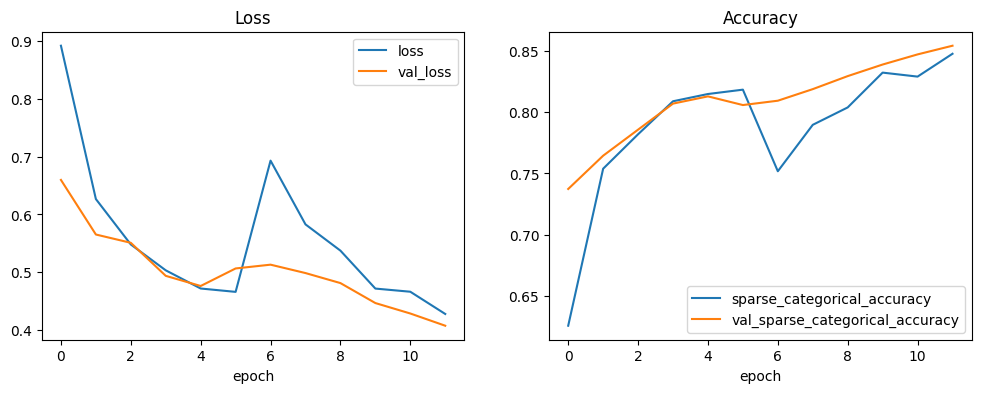

53/53 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step


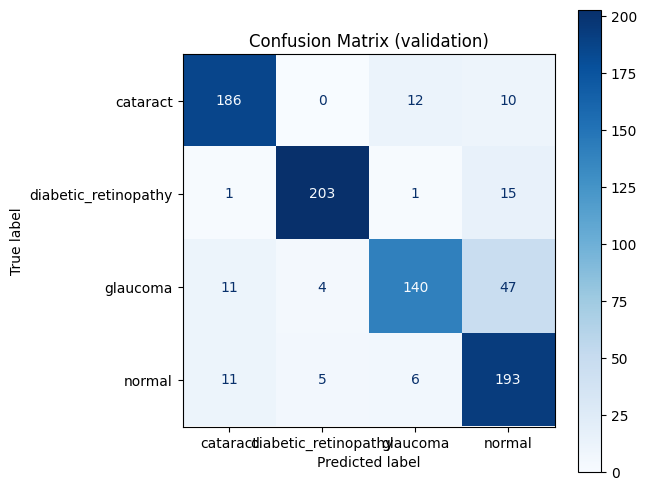

                      precision    recall  f1-score   support

            cataract     0.8900    0.8942    0.8921       208
diabetic_retinopathy     0.9575    0.9227    0.9398       220
            glaucoma     0.8805    0.6931    0.7756       202
              normal     0.7283    0.8977    0.8042       215

            accuracy                         0.8544       845
           macro avg     0.8641    0.8519    0.8529       845
        weighted avg     0.8642    0.8544    0.8543       845



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

hist = combined_hist

# accuracy vs loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.get("loss", []), label="loss")
if hist.get("val_loss"):
    plt.plot(hist.get("val_loss"), label="val_loss")
plt.legend(); plt.title("Loss"); plt.xlabel("epoch")

plt.subplot(1,2,2)
for key in ("sparse_categorical_accuracy","accuracy","acc"):
    if key in hist:
        plt.plot(hist[key], label=key)
        if "val_" + key in hist:
            plt.plot(hist["val_" + key], label="val_"+key)
        break
plt.legend(); plt.title("Accuracy"); plt.xlabel("epoch")
plt.show()

# Confusion matrix on val set
y_true = val_gen.classes
steps = len(val_gen)
y_score = model.predict(val_gen, steps=steps, verbose=1)
if y_score.ndim == 2 and y_score.shape[1] == 1:
    y_pred = (y_score[:,0] >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_score, axis=1)

cm = confusion_matrix(y_true, y_pred)
labels = [class_labels[i] for i in range(len(class_labels))]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix (validation)")
plt.show()

# classification report
print(classification_report(y_true, y_pred, target_names=labels, digits=4))